# 🎬 Storyboard Agent (LangGraph)

먹방 스토리보드 제작 에이전트

---
## 1. 환경 설정

In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv
from langchain_teddynote import logging

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
load_dotenv(PROJECT_ROOT / ".env")

# 프로젝트 이름을 입력합니다.
logging.langsmith("tzudong-agent")

print(f"✅ 프로젝트 루트: {PROJECT_ROOT}")
print(f"✅ OPENAI_API_KEY: {'설정됨' if os.getenv('OPENAI_API_KEY') else '미설정'}")

LangSmith 추적을 시작합니다.
[프로젝트명]
tzudong-agent
✅ 프로젝트 루트: /Users/byeon-ujung/Desktop/programming/tzudong_pjt/tzudong/backend/storyboard-agent
✅ OPENAI_API_KEY: 설정됨


---
## 2. 도구 로드

In [2]:
from tools import TOOLS

print(f"📦 총 {len(TOOLS)}개 도구 로드됨")
for i, tool in enumerate(TOOLS, 1):
    print(f"{i}. {tool.name}")

📦 총 8개 도구 로드됨
1. search_video_ids_by_query
2. search_transcripts_hybrid
3. search_restaurants_by_category
4. get_video_metadata_filtered
5. get_categories_by_restaurant
6. search_restaurants_by_name
7. get_all_approved_restaurant_names
8. tavily_web_search


---
## 3. State 정의

In [3]:
from typing import Annotated, List, Optional, Literal, TypedDict
from langchain_core.messages import BaseMessage
from langchain_core.documents import Document
from langgraph.graph.message import add_messages
import operator


class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    intent: Literal["simple_chat", "qna_about_data", "storyboard"]
    loop_count: int
    retry_count: int

    transcript_docs: List[Document]
    web_search_docs: Annotated[List[Document], operator.add]

    validation_status: Literal["pass", "fail", "need_human", "pending"]
    validation_feedback: Optional[str]
    previous_queries: Annotated[list[str], operator.add]

    active_query: Optional[str]
    human_feedback: Optional[str]

    final_output: Optional[str]


print("✅ AgentState 정의 완료")

✅ AgentState 정의 완료


📋 AgentState 필드별 활용 명세
&nbsp;
&nbsp;
1. messages (대화 기록)

    - 역할: LLM과 사용자, 도구(Tool) 간의 주고받은 모든 메시지 리스트 (add_messages로 계속 누적됨)

    - 🛠 변경 (Write):
        - orchestrator: LLM이 도구를 호출하거나 답변할 때 메시지 추가
        - simple_response: 단순 잡담에 대한 답변 추가
        - tool_node (LangGraph 내장): 도구 실행 결과(ToolMessage) 추가
        - human_request: 사용자의 피드백(HumanMessage) 추가

    - 👀 참조 (Read):
        - intent_router: 마지막 메시지를 분석하여 의도 파악
        - orchestrator: 이전 대화 맥락을 보고 다음 행동 결정

&nbsp;

2. intent (사용자 의도)
  
    - 역할: 현재 작업이 잡담인지, 데이터 질문인지, 스토리보드 생성인지 구분

    - 🛠 변경:
        - intent_router: 사용자 입력을 분류하여 설정 (simple_chat | qna_about_data | storyboard)
    
    - 👀 참조:
        - orchestrator: 의도에 따라 프롬프트(SystemMessage)와 데이터 요약 방식 변경
        - validate_data: 검증 기준 변경 (스토리보드는 캡션 필수, Q&A는 텍스트만 있어도 통과)
        - human_request: 사람에게 보여줄 데이터 요약 방식 결정
        - 🔀 분기: route_after_intent, route_after_validator, route_after_human에서 다음 노드 결정용

&nbsp;

3. transcript_docs (자막 데이터)
  
    - 역할: 수집된 영상 자막/캡션 데이터 리스트 (덮어쓰기 아님, operator.add 방식 혹은 로직 내 병합)
  
    - 🛠 변경:
        - orchestrator: 도구(search_transcripts_*) 결과에서 transcripts 키가 있으면 중복 제거 후 추가/업데이트
  
    - 👀 참조:
        - orchestrator: 현재 수집된 데이터 현황 요약 프롬프트 생성
        - validate_data: 데이터 개수(3개 이상 등) 및 캡션 유무 확인
        - human_request: 사용자에게 현재 수집된 내용 출력
        - generate_storyboard / qna_responder: 최종 결과물 생성 시 문맥(Context)으로 주입

&nbsp;

4. web_search_docs (웹/메타 데이터)
  
    - 역할: 유튜브 메타데이터나 웹 검색 결과 (operator.add로 누적)
  
    - 🛠 변경:
        - orchestrator: 도구 결과에서 videos(메타데이터)나 일반 텍스트(웹검색)가 오면 추가
  
    - 👀 참조:
        - validate_data: 보조 데이터 개수 확인
        - generate_storyboard / qna_responder: 최종 생성 시 보조 정보로 활용

&nbsp;

5. validation_status (검증 상태)
  
    - 역할: 데이터가 충분한지 판별 (pass | fail | need_human)
  
    - 🛠 변경:
        - validate_data: 수집된 transcript_docs 개수와 retry_count를 보고 상태 결정
  
    - 👀 참조:
        - orchestrator: fail일 경우, 다음 턴 프롬프트에 "이전 검색 실패함, 다른 키워드 써라"는 힌트 추가
    - 🔀 분기: route_after_validator에서 orchestrator(재검색)로 갈지, human_request(사람 개입)로 갈지 결정

&nbsp;

6. validation_feedback (검증 피드백)
  
    - 역할: 왜 검증에 실패했는지, 무엇이 부족한지 설명하는 텍스트
    
    - 🛠 변경:
      - validate_data: "캡션이 0개입니다", "3개 부족합니다" 등의 사유 저장
    
    - 👀 참조:
      - orchestrator: LLM에게 "이 점을 보완해라"고 지시하는 시스템 메시지에 포함
      - human_request: 사용자에게 "⚠️ 부족한 점"으로 출력

&nbsp;

7. retry_count (재시도 횟수)
  
    - 역할: 에이전트가 사람 개입 없이 스스로 재검색한 횟수
  
    - 🛠 변경:
        - validate_data: 검증 실패(fail) 시 +1 증가
  
    - 🔀 분기: validate_data 내부에서 3회 이상 실패 시 need_human상태로 변경하여 사람 호출

&nbsp;

8. previous_queries (검색어 기록)
  
    - 역할: 중복 검색 방지를 위해 사용한 검색어 저장
  
    - 🛠 변경:
        - orchestrator: 도구 호출 메시지(tool_calls)를 감지하여 사용된 쿼리를 리스트에 추가
  
    - 👀 참조:
    - orchestrator: LLM 시스템 프롬프트에 "이 검색어들은 이미 썼으니 피하라"고 힌트 제공

&nbsp;

9. active_query (활성 쿼리)
  
    - 역할: 사용자의 최초 요청 사항 보존 (재검색 중 메시지가 쌓여도 원래 목적 잃지 않기 위함)
  
    - 🛠 변경:
        - intent_router: 맨 처음 사용자 입력을 저장
  
    - 👀 참조:
        - generate_storyboard / qna_responder: 최종 결과 생성 시 "사용자의 원래 질문"으로 사용

&nbsp;

10. human_feedback (사람 피드백)
  
    - 역할: human_request 노드에서 사용자가 입력한 값 ("2", "라면으로 다시 검색해" 등)
  
    - 🛠 변경:
        - human_request: interrupt 함수로 받은 사용자 입력을 저장
  
    - 👀 참조:
        - generate_storyboard: 사용자가 추가로 요청한 사항("좀 더 신나게 해줘" 등) 반영
        - 🔀 분기: route_after_human에서 "2"인지 아닌지 판단하여 진행 여부 결정

&nbsp;

11. loop_count (루프 횟수)
  
    - 역할: 무한 루프 방지용 안전 장치
    
    - 🛠 변경:
        - orchestrator: 실행될 때마다 +1
    
    - 👀 참조: 코드상 명시적 참조는 없으나, 디버깅이나 강제 종료 조건으로 확장 가능

&nbsp;

12. final_output (최종 결과)
  
    - 역할: 에이전트의 최종 산출물 (스토리보드 텍스트 또는 답변)
    
    - 🛠 변경:
        - generate_storyboard: 생성된 스토리보드 저장
        - qna_responder: 생성된 답변 저장
    
    - 👀 참조: 그래프 종료 후 사용자에게 반환되는 값

---
## 4. 노드 정의

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5.2", temperature=0)
llm_mini = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print("✅ LLM 초기화 완료")

/opt/anaconda3/envs/tzudong/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ LLM 초기화 완료


In [5]:
# 4.1 Intent Router
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field


class IntentClassification(BaseModel):
    intent: Literal["simple_chat", "qna_about_data", "storyboard"] = Field(
        description="simple_chat: 잡담, qna_about_data: 데이터 질문, storyboard: 스토리보드 기획"
    )


router_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """사용자 입력을 분류하세요:
- simple_chat: 인사, 잡담
- qna_about_data: 데이터/정보 질문 ("~몇 개야?", "~알려줘")
- storyboard: 영상 기획 요청 ("~짜줘", "~기획해줘")""",
        ),
        ("human", "{input}"),
    ]
)

intent_classifier = router_prompt | llm_mini.with_structured_output(
    IntentClassification
)


def intent_router(state: AgentState) -> dict:
    last_message = state["messages"][-1].content
    result = intent_classifier.invoke({"input": last_message})
    return {"intent": result.intent, "active_query": last_message}


print("✅ Intent Router 정의 완료")

✅ Intent Router 정의 완료


In [6]:
# 4.2 Orchestrator
import json
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode

llm_with_tools = llm.bind_tools(TOOLS)


def orchestrator(state: AgentState) -> dict:
    updates = {}
    last_msg = state["messages"][-1]
    intent = state.get("intent", "qna_about_data")

    # 이전 쿼리 기록 확인 및 현재 툴 호출에서 쿼리 추출
    previous_queries = state.get("previous_queries", [])

    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        new_queries = []
        for tool_call in last_msg.tool_calls:
            query_used = tool_call["args"].get("query")
            # 쿼리가 있고, 아직 기록되지 않았다면 추가 (중복 방지)
            if (
                query_used
                and query_used not in previous_queries
                and query_used not in new_queries
            ):
                new_queries.append(query_used)
                previous_queries.append(query_used)  # 현재 로직용 임시 추가

        # 새로 추가된 쿼리가 있다면 한 번에 업데이트 (Append)
        if new_queries:
            updates["previous_queries"] = new_queries
    # === [수정된 부분 끝] ===

    # Tool 결과 분류 및 저장
    if hasattr(last_msg, "type") and last_msg.type == "tool":
        try:
            data = json.loads(last_msg.content)

            if "transcripts" in data:
                new_docs = [
                    Document(
                        page_content=t["page_content"], metadata=t.get("metadata", {})
                    )
                    for t in data["transcripts"]
                ]
                existing = state.get("transcript_docs", []) or []
                existing_keys = {
                    (d.metadata.get("video_id"), d.metadata.get("chunk_index"))
                    for d in existing
                }
                deduped = [
                    d
                    for d in new_docs
                    if (d.metadata.get("video_id"), d.metadata.get("chunk_index"))
                    not in existing_keys
                ]
                updates["transcript_docs"] = existing + deduped

            elif "videos" in data:  # [수정] 비디오 메타데이터 포맷팅
                summary_text = "[관련 비디오 목록]\n"
                for v in data["videos"]:
                    summary_text += f"- 제목: {v.get('title')}, 조회수: {v.get('view_count')}, ID: {v.get('id')}\n"

                # 명시적으로 'video_metadata' 타입 지정
                doc = Document(
                    page_content=summary_text, metadata={"type": "video_metadata"}
                )
                updates["web_search_docs"] = [doc]

            elif "video_ids" in data:  # video id 수집 툴 호출 시
                pass
            else:
                doc = Document(page_content=str(data), metadata={"type": "web_search"})
                updates["web_search_docs"] = [doc]
        except Exception as e:
            print(f"Tool 결과 파싱 오류: {e}")

    # 현재 데이터 가져오기
    transcript_docs = (
        updates.get("transcript_docs") or state.get("transcript_docs", []) or []
    )
    web_search_docs = state.get("web_search_docs", []) or []

    # Validation Status 확인
    val_status = state.get("validation_status")
    val_feedback = state.get("validation_feedback")

    # [추가] 이전 쿼리 목록 문자열 생성
    prev_query_str = ", ".join([f"'{q}'" for q in previous_queries])

    # 전체 데이터 내용 구성 (잘라내기 없음!)
    if intent == "storyboard":
        docs_with_caption = [d for d in transcript_docs if d.metadata.get("caption")]

        data_summary = (
            f"\n=== 수집된 데이터 (캡션 있는 자막: {len(docs_with_caption)}개) ===\n"
        )
        for i, doc in enumerate(docs_with_caption, 1):
            data_summary += f"\n[{i}] 자막: {doc.page_content}\n"
            data_summary += f"    캡션: {doc.metadata.get('caption', '없음')}\n"

        if web_search_docs:
            data_summary += f"\n=== 추가 수집 정보 (메타데이터/웹) ===\n"
            for doc in web_search_docs:
                data_summary += f"{doc.page_content}\n"

        # 힌트 구성 (검증 실패 시 강력한 경고 추가)
        if val_status == "fail" and val_feedback:
            hint = f"""🚨 [주의] 이전 시도가 실패했습니다: {val_feedback}
이미 사용한 검색어 목록: [{prev_query_str}]
위 검색어들은 이미 실패했으므로, 재사용하지 말고 **전혀 다른 키워드**를 사용하세요."""
        else:
            hint = f"""캡션 있는 자막 3개 이상 또는 (캡션 + 웹검색) 3개 이상이면 충분합니다.
현재: 캡션 있는 자막 {len(docs_with_caption)}개, 추가정보 {len(web_search_docs)}건
이전에 사용한 검색어: [{prev_query_str}] (중복 검색 지양)
부족하면 search_transcripts_hybrid(intent='storyboard')를 호출하세요.
만약 관련 영상을 먼저 찾고 싶다면 search_video_ids_by_query 도구를 사용할 수 있습니다."""

    else:  # qna_about_data
        data_summary = f"\n=== 수집된 자막: {len(transcript_docs)}개 ===\n"
        for i, doc in enumerate(transcript_docs, 1):
            data_summary += f"[{i}] {doc.page_content}\n"

        hint = f"자막이 있으면 질문에 답변할 수 있습니다. 부족하면 도구를 호출하세요."

    system_msg = SystemMessage(
        content=f"""당신은 먹방 유튜브 기획 전문가입니다.
현재 intent: {intent}

{data_summary}

{hint}

데이터가 충분하면 도구 호출 없이 답변하세요."""
    )

    response = llm_with_tools.invoke([system_msg] + state["messages"])

    updates["messages"] = [response]
    updates["loop_count"] = (state.get("loop_count") or 0) + 1

    return updates


print("✅ Orchestrator 정의 완료 (메타데이터 파싱 개선)")

✅ Orchestrator 정의 완료 (메타데이터 파싱 개선)


In [7]:
# 4.3 Data Validator
def validate_data(state: AgentState) -> dict:
    transcript_docs = state.get("transcript_docs", []) or []
    web_search_docs = state.get("web_search_docs", []) or []
    retry_count = state.get("retry_count", 0) or 0
    intent = state.get("intent", "qna_about_data")

    if intent == "storyboard":
        docs_with_caption = [d for d in transcript_docs if d.metadata.get("caption")]
        caption_count = len(docs_with_caption)
        web_count = len(web_search_docs)

        if caption_count >= 3:
            return {
                "validation_status": "pass",
                "validation_feedback": f"캡션 {caption_count}개 확보",
            }
        if caption_count + web_count >= 3:
            return {
                "validation_status": "pass",
                "validation_feedback": f"캡션 {caption_count}개 + 웹 {web_count}개",
            }
        if retry_count < 3:
            feedback = f"캡션 있는 자막 {caption_count}개, 웹검색 {web_count}개로 부족합니다.\n"
            if caption_count == 0:
                feedback += (
                    "시각적 묘사(캡션)가 전혀 없어 스토리보드 작성이 어렵습니다."
                )
            else:
                feedback += f"최소 3개의 시각 자료가 필요합니다. {3 - caption_count - web_count}개 더 필요합니다."
            return {
                "validation_status": "fail",
                "validation_feedback": feedback,
                "retry_count": retry_count + 1,
            }
        return {
            "validation_status": "need_human",
            "validation_feedback": "재검색 후에도 시각 자료가 부족합니다.",
        }

    else:  # qna_about_data
        if len(transcript_docs) > 0 or len(web_search_docs) > 0:
            return {"validation_status": "pass", "validation_feedback": "답변 가능"}
        if retry_count < 3:
            return {
                "validation_status": "fail",
                "validation_feedback": "관련 정보를 찾지 못했습니다. 다른 키워드로 재검색합니다.",
                "retry_count": retry_count + 1,
            }
        return {
            "validation_status": "need_human",
            "validation_feedback": "정보를 찾지 못했습니다.",
        }


print("✅ Validator 정의 완료")

✅ Validator 정의 완료


In [8]:
# 4.4 Human Request (전체 내용 표시 + 부족한 점 설명)
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.types import interrupt


def human_request(state: AgentState) -> dict:
    transcript_docs = state.get("transcript_docs", []) or []
    web_search_docs = state.get("web_search_docs", []) or []
    intent = state.get("intent", "qna_about_data")
    validation_feedback = state.get("validation_feedback", "정보가 부족합니다.")

    # 전체 내용 표시 (잘라내기 없음!)
    content_lines = []

    if intent == "storyboard":
        docs_with_caption = [d for d in transcript_docs if d.metadata.get("caption")]
        content_lines.append(
            f"📊 캡션 있는 자막: {len(docs_with_caption)}개, 웹검색: {len(web_search_docs)}개"
        )

        if docs_with_caption:
            content_lines.append("\n[수집된 자막+캡션]")
            for i, doc in enumerate(docs_with_caption, 1):
                content_lines.append(f"  {i}. 자막: {doc.page_content}")
                content_lines.append(
                    f"     캡션: {doc.metadata.get('caption', '없음')}"
                )

        if web_search_docs:
            content_lines.append("\n[웹검색 결과]")
            for i, doc in enumerate(web_search_docs, 1):
                content_lines.append(f"  {i}. {doc.page_content}")
    else:
        content_lines.append(
            f"📊 자막: {len(transcript_docs)}개, 웹검색: {len(web_search_docs)}개"
        )

        if transcript_docs:
            content_lines.append("\n[수집된 자막]")
            for i, doc in enumerate(transcript_docs, 1):
                content_lines.append(f"  {i}. {doc.page_content}")

    question = f"""현재 수집된 정보:
{chr(10).join(content_lines)}

⚠️ 부족한 점:
{validation_feedback}

어떻게 할까요?
1. 다시 검색 (검색어를 입력하세요)
2. 현재 정보로 진행"""

    user_response = interrupt(question)

    # [중요 수정] messages 키에 HumanMessage를 추가해야 오케스트레이터가 인지함
    return {
        "human_feedback": user_response,
        "messages": [HumanMessage(content=user_response)],
    }


print("✅ Human Request 정의 완료")

✅ Human Request 정의 완료


In [9]:
# 4.5 Storyboard Generator (캡션 있는 자막만, 전체 내용)
from langchain_core.prompts import ChatPromptTemplate

generator_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """사용자의 요청에 따라 먹방 유튜브 영상의 하이라이트 부분 스토리보드 짜야합니다.
아래의 정보를 활용해서 사람들이 많이 볼 수 있도록 사용자의 요청에 맞는 연속적인 6개~8개 사이의 장면에 대한 스토리보드를 짜세요.
[중요 지침]
- 인물 지칭:
  유튜버의 실제 이름은 사용하지 않으며,
  모든 인물은 항상 ‘유튜버’로 표현합니다.

- 장면 구성 방식:
  캡션 데이터를 기반으로 사람들이 많이 본 장면의
  촬영 대상, 구도, 흐름, 연출 포인트를 중심으로 장면을 설계합니다.
  이 과정에서 대사와 오디오도 함께 고려하되,
  **장면의 구조와 연출이 대사보다 우선되도록 합니다.**

- 자막 활용 원칙:
  자막은 유튜버의 말투, 말의 리듬, 감정 표현을 참고하기 위한 자료입니다.
  자막에 등장한 특정 사물, 사건, 행동(예: 특정 음식, 인물에게 무언가를 건네는 장면 등)을
  그대로 차용하거나 재현하지 않습니다.
  설계된 장면 연출에 어울리도록 의미를 일반화하고 재구성하여 대사를 작성합니다.

[참고]
캡션 데이터: "사람들이 가장 많이 본 장면에 대해 어떤 대상을 어떻게 촬영하여 그 대상이 어떻게 보이는지"를 정리해 놓은 것입니다(여러 장면 있을 수 있음).
자막 데이터: 캡션 데이터 그 주변대의 자동 생성 자막과 그 자막의 문맥을 함께 합쳐놓은 자막입니다. 이를 참고하여 인물의 대사나 상황을 묘사하세요.

[자막 + 캡션 데이터]
{transcript_context}

[웹 검색 정보]
{web_context}

[사용자 추가 요청]
{human_feedback}

스토리보드 형식:
# 제목: (전체 스토리보드 제목)
# 컨셉: (스토리보드 컨셉)
## 📍 씬 1: (씬 제목)
- 영상: (어떤 대상을 어떻게 촬영했고, 어떻게 보이는지 등을 최대한 자세히 서술)
- 오디오: (대사/효과음/자막)
- 연출 포인트: (장면의 키포인트)""",
        ),
        ("human", "{query}"),
    ]
)


def generate_storyboard(state: AgentState) -> dict:
    transcript_docs = state.get("transcript_docs", []) or []
    web_search_docs = state.get("web_search_docs", []) or []
    human_feedback = state.get("human_feedback") or "없음"

    # 캡션 있는 자막만 필터링
    docs_with_caption = [d for d in transcript_docs if d.metadata.get("caption")]

    # 전체 내용 전달
    transcript_context = (
        "\n\n".join(
            [
                f"[자막] {doc.page_content}\n[캡션] {doc.metadata.get('caption', '없음')}"
                for doc in docs_with_caption
            ]
        )
        or "없음"
    )

    web_context = "\n".join([doc.page_content for doc in web_search_docs]) or "없음"
    query = state.get("active_query") or state["messages"][0].content

    chain = generator_prompt | llm
    result = chain.invoke(
        {
            "transcript_context": transcript_context,
            "web_context": web_context,
            "human_feedback": human_feedback,
            "query": query,
        }
    )

    return {"final_output": result.content}


print("✅ Generator 정의 완료")

✅ Generator 정의 완료


In [10]:
# 4.6 QnA Responder (자막 전체 사용)
qna_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """당신은 먹방 데이터 전문가입니다.
아래 정보를 활용하여 사용자 질문에 답변하세요.

[자막 데이터]
{transcript_context}

[웹 검색 정보]
{web_context}""",
        ),
        ("human", "{query}"),
    ]
)


def qna_responder(state: AgentState) -> dict:
    transcript_docs = state.get("transcript_docs", []) or []
    web_search_docs = state.get("web_search_docs", []) or []

    # 자막 전체 사용 (캡션 필터링 없음)
    transcript_context = (
        "\n".join([f"- {doc.page_content}" for doc in transcript_docs]) or "없음"
    )

    web_context = "\n".join([doc.page_content for doc in web_search_docs]) or "없음"
    query = state.get("active_query") or state["messages"][0].content

    chain = qna_prompt | llm
    result = chain.invoke(
        {
            "transcript_context": transcript_context,
            "web_context": web_context,
            "query": query,
        }
    )

    return {"final_output": result.content}


print("✅ QnA Responder 정의 완료")

✅ QnA Responder 정의 완료


---
## 5. 그래프 구성

In [11]:
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

tool_node = ToolNode(TOOLS)


def route_after_intent(state: AgentState) -> str:
    if state.get("intent") == "simple_chat":
        return "simple_response"
    return "orchestrator"


def route_after_orchestrator(state: AgentState) -> str:
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "tools"
    return "validator"


def route_after_validator(state: AgentState) -> str:
    status = state.get("validation_status")
    intent = state.get("intent")

    if status == "pass":
        return "generator" if intent == "storyboard" else "qna_responder"
    elif status == "need_human":
        return "human_request"
    return "orchestrator"


def route_after_human(state: AgentState) -> str:
    feedback = state.get("human_feedback", "")
    intent = state.get("intent")

    if feedback == "2" or "현재" in feedback or "진행" in feedback:
        return "generator" if intent == "storyboard" else "qna_responder"
    return "orchestrator"


def simple_response(state: AgentState) -> dict:
    response = llm_mini.invoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(AgentState)

builder.add_node("intent_router", intent_router)
builder.add_node("simple_response", simple_response)
builder.add_node("orchestrator", orchestrator)
builder.add_node("tools", tool_node)
builder.add_node("validator", validate_data)
builder.add_node("human_request", human_request)
builder.add_node("generator", generate_storyboard)
builder.add_node("qna_responder", qna_responder)

builder.set_entry_point("intent_router")

builder.add_conditional_edges(
    "intent_router",
    route_after_intent,
    {"simple_response": "simple_response", "orchestrator": "orchestrator"},
)
builder.add_edge("simple_response", END)

builder.add_conditional_edges(
    "orchestrator",
    route_after_orchestrator,
    {"tools": "tools", "validator": "validator"},
)
builder.add_edge("tools", "orchestrator")

builder.add_conditional_edges(
    "validator",
    route_after_validator,
    {
        "generator": "generator",
        "qna_responder": "qna_responder",
        "human_request": "human_request",
        "orchestrator": "orchestrator",
    },
)

builder.add_conditional_edges(
    "human_request",
    route_after_human,
    {
        "generator": "generator",
        "qna_responder": "qna_responder",
        "orchestrator": "orchestrator",
    },
)

builder.add_edge("generator", END)
builder.add_edge("qna_responder", END)

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

print("✅ 그래프 컴파일 완료")

✅ 그래프 컴파일 완료


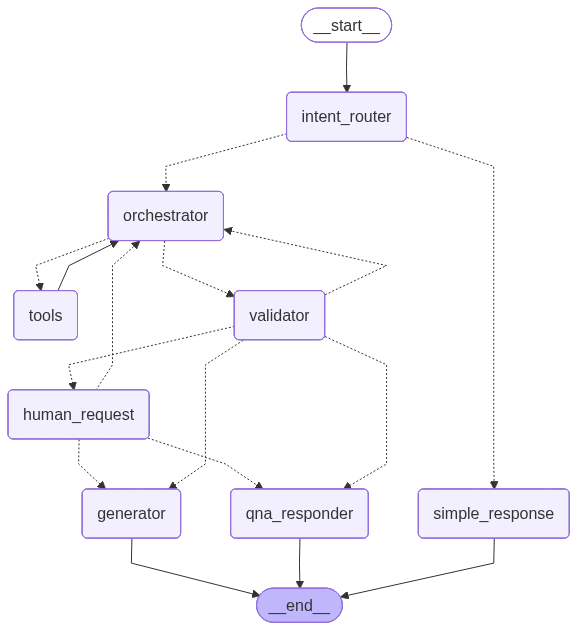

In [12]:
try:
    from IPython.display import Image, display

    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(graph.get_graph().draw_mermaid())

---
## 6. 테스트

In [13]:
from langchain_core.messages import HumanMessage

test_query = "이번 주에 매운 치킨을 먹고자 해. 관련 먹방 참고해서 스토리보드 짜줘. 이번에는 게스트 한 분과 같이 먹을거야."
thread_id = "test-1"

initial_state = {
    "messages": [HumanMessage(content=test_query)],
    "intent": "storyboard",
    "loop_count": 0,
    "retry_count": 0,
    "transcript_docs": [],
    "web_search_docs": [],
    "validation_status": "pending",
    "validation_feedback": None,
    "active_query": test_query,
    "human_feedback": None,
    "final_output": None,
}

config = {"configurable": {"thread_id": thread_id}}

print(f"🚀 테스트: {test_query}\n")

for event in graph.stream(initial_state, config=config):
    for node, values in event.items():
        print(f"\n📍 [{node}]")
        if node == "__interrupt__":
            # interrupt 질문 출력
            print(f"\n💬 사용자 입력 대기:\n{values[0].value}")
        if "validation_status" in values:
            print(f"   검증: {values['validation_status']}")
        if "final_output" in values:
            print(f"\n📋 최종 출력:\n{values['final_output']}")

🚀 테스트: 이번 주에 매운 치킨을 먹고자 해. 관련 먹방 참고해서 스토리보드 짜줘. 이번에는 게스트 한 분과 같이 먹을거야.


📍 [intent_router]

📍 [orchestrator]


Fetching 30 files: 100%|██████████| 30/30 [00:00<00:00, 56501.63it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



📍 [tools]

📍 [orchestrator]

📍 [tools]

📍 [orchestrator]

📍 [validator]
   검증: fail

📍 [orchestrator]

📍 [tools]

📍 [orchestrator]

📍 [validator]
   검증: fail

📍 [orchestrator]

📍 [tools]

📍 [orchestrator]

📍 [validator]
   검증: fail

📍 [orchestrator]

📍 [tools]

📍 [orchestrator]

📍 [validator]
   검증: need_human

📍 [__interrupt__]

💬 사용자 입력 대기:
현재 수집된 정보:
📊 캡션 있는 자막: 2개, 웹검색: 0개

[수집된 자막+캡션]
  1. 자막: 문맥: 쯔양이 BBQ 신메뉴 치킨을 먹으면서 매운 맛을 평가하는 장면입니다. 그녀는 치킨의 짭짤하고 알싸한 맛이 기존 크리스피보다 매콤한 점이 좋다고 말하며, 남자친구를 만나러 가는 길에 남은 음식을 나눠먹겠다고 합니다. 이 장면은 먹방 중 친구들과의 대화와 함께, 매운 음식에 대한 그녀의 솔직한 반응을 보여줍니다.

[04:16] 잘생겼잖아. 네가 잘생겼으면 나는 여신이다. 여신 거기서 오진 거 같은데씨. 야 근데 너는 여기서 뭐가 제일 맛있냐? 이거 이거 이거 그거 약간음 짭짤한데 알싸하고 근데 지것보다 나는 이게 약간 기존 크리시피보다 살짝 매콤한게 맛있어. 야 이거양도 1인이 딱 하겠다. 이거 두 개는 너무 매워. 나한테 매운 거 잘 먹어서 부럽다. 맞지? [음악] 뭐 뭐 하나 그거? 야 말걸지 마. [음악] 아 자꾸 매운데 자꾸 당기네. [음악] 음. [음악] 누나 이거 엄청 었어. 응. 그래.
[05:21] [음악] 어. [음악] 나 잘 먹었어. 나 이제 간다. 야, 너 어디 가? 렘 연습하러 가야지. 아휴 맵 같은 소리하고 언니 뭐야 또 먹어? 뭐야? 너 집에 있었어? 어 나 아까부터 있었는데 어딜 나가려고 부했어? 나 남자 친구 만나러 가

In [ ]:
from langgraph.types import Command

# 방법 1: 직접 코드에 입력 (원하는 검색어 또는 "2")
user_feedback = "2"

# 방법 2: 실행 시 입력창 띄우기 (주석 해제 후 사용)
# user_feedback = input("명령 입력 (검색어 또는 2): ")

print(f"🚀 사용자 입력 전달: {user_feedback}")

# 중단된 지점(human_request)에 resume 값을 전달하며 실행 재개
for event in graph.stream(Command(resume=user_feedback), config=config):
    for node, values in event.items():
        print(f"\n📍 [{node}]")

        if "validation_status" in values:
            print(f"   검증: {values['validation_status']}")

        if "final_output" in values:
            print(f"\n📋 최종 출력:\n{values['final_output']}...")

보통, 1분 ~ 2분 30초 걸림

"이번 주에 매운 치킨을 먹고자 해. 관련 먹방 참고해서 스토리보드 짜줘. 이번에는 게스트 한 분과 같이 먹을거야."

-> 3개 캡셔닝 가져오기 실패. 161,204 tokens / $0.28695485
